In [ ]:
# Import libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For text processing
import re
import os
from collections import Counter

# For feature extraction (n-grams)
from sklearn.feature_extraction.text import CountVectorizer

In [74]:
# Load dataset from CSV file

df = pd.read_csv("D:\\SOMALI-NLP-RESEARCH\\data\\raw\\full_dataset.csv")

In [75]:
# Display first rows of the dataset

print(df.head())

                                                Text  \
0  Madaxa Kooxda Barcelona, Laporta ayaa xaqiijiy...   
1  Ra'iisul Wasaare Maxamed Xuseen Rooble ayaa da...   
2  Maxamed Farax oo u orda Britain, walaakii ka y...   
3  Weeraryahanka Ajax iyo xulka Brazil Antony, oo...   
4  Wasiiru Dowlaha Wasaaradda Waxbarashada, Hidda...   

                                                Link   Category    Type  \
0  Antoine Griezmann: Sababta ay Atletico Madrid ...     Sports   Large   
1  https://www.hiiraan.com/news/2022/Jun/wararka_...  Education  Medium   
2            https://www.bbc.com/somali/war-50807903     Sports   Large   
3   https://www.bbc.com/somali/articles/cmjelvxy2mgo     Sports   Large   
4  https://www.hiiraan.com/news/2022/Mar/wararka_...  Education   Large   

        Date                                       Summarize Ai  \
0  10-Oct-22  Shirka Madasha Iskaashiga Soomaaliya ayaa maan...   
1  18-Jun-22  Imtixaanka shahaadiga ah ee dugsiyada sare waa...   
2  16-Dec-1

In [76]:
print(df.columns)

Index(['Text', 'Link', 'Category', 'Type', 'Date', 'Summarize Ai', 'Expand Ai',
       'Ai Type', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25'],
      dtype='object')


In [77]:
# remove unnamed columns if they exist
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

In [78]:
print(df.columns)

Index(['Text', 'Link', 'Category', 'Type', 'Date', 'Summarize Ai', 'Expand Ai',
       'Ai Type'],
      dtype='object')


In [79]:
# Select only the relevant/needed columns for analysis
df = df[['Text', 'Category']]

In [80]:
df.isnull().sum()

Text        995
Category    994
dtype: int64

In [81]:
# Remove missing values from key columns
df = df.dropna(subset=['Text', 'Category'])

# Ensure text is string
df['Text'] = df['Text'].astype(str)

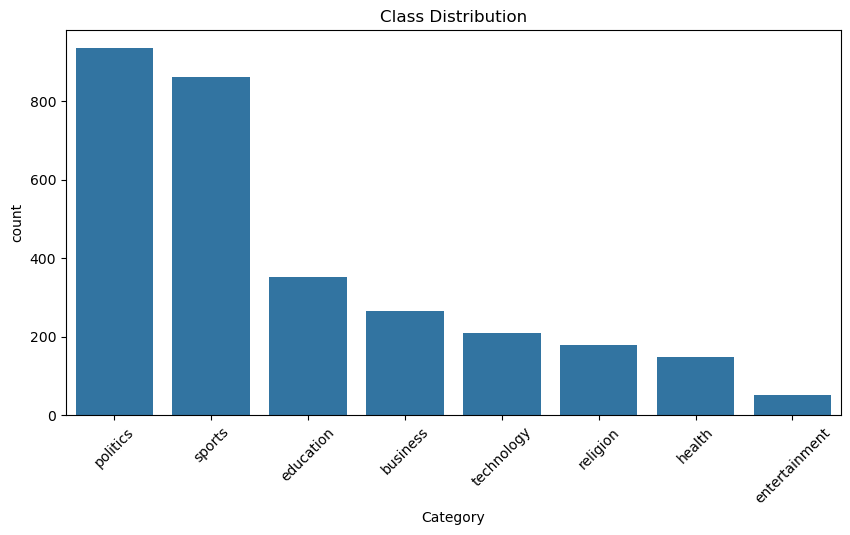

In [116]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure folder exists
os.makedirs("eda/figures", exist_ok=True)

# Visualize class distribution
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Category',
    order=df['Category'].value_counts().index
)

plt.title("Class Distribution")

# Rotate labels
plt.xticks(rotation=45)

# Save figure
plt.savefig(
    "eda/figures/class_distribution.png",
    bbox_inches='tight'
)

# Show plot
plt.show()

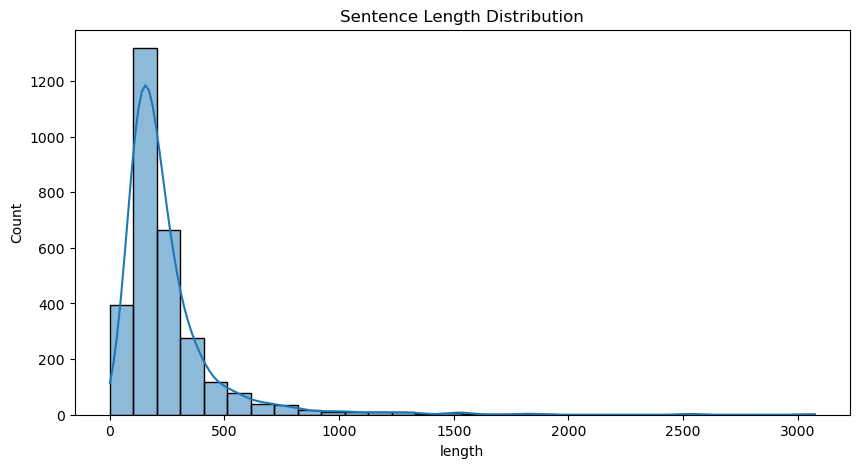

In [83]:
# Calculate number of words in each sentence
df['length'] = df['Text'].apply(lambda x: len(str(x).split()))

# Plot sentence length distribution
plt.figure(figsize=(10,5))
sns.histplot(df['length'], bins=30, kde=True)

# Add title
plt.title("Sentence Length Distribution")

# Show plot
plt.show()

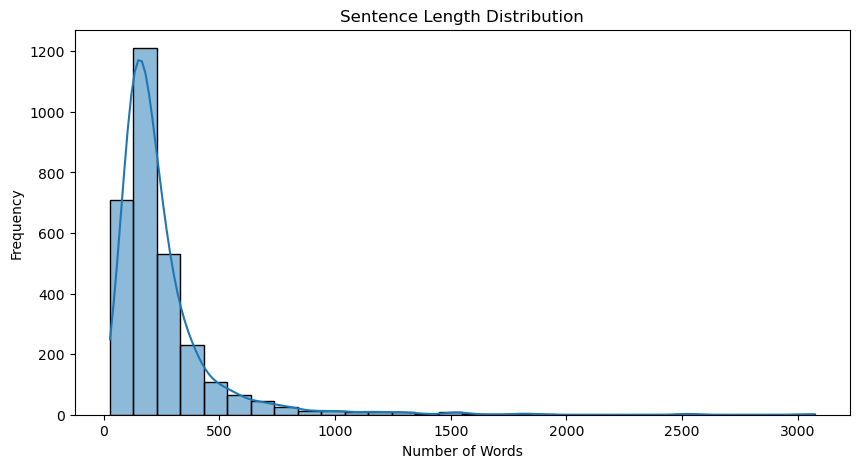

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure output folder exists
os.makedirs("eda/figures", exist_ok=True)

# 1. Sentence length feature
df['length'] = df['Text'].apply(lambda x: len(str(x).split()))

# 2. Plot distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df['length'],
    bins=30,
    kde=True
)

# Title
plt.title("Sentence Length Distribution")

# Label axes (good for report)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

# 3. Save figure
plt.savefig(
    "eda/figures/sentence_length_hist.png",
    bbox_inches='tight'
)

# 4. Show plot
plt.show()

In [84]:
# Function to clean text data
def clean_text(text):

     if pd.isnull(text):
        return ""
     
    # Convert text to lowercase
     text = str(text).lower()

    # Remove punctuation and numbers
     text = re.sub(r'[^a-zA-Z\s]', '', text)
     return text


# Apply cleaning function to dataset
df['clean_text'] = df['Text'].apply(clean_text)

In [85]:
df = df[df['clean_text'].str.strip() != ""]

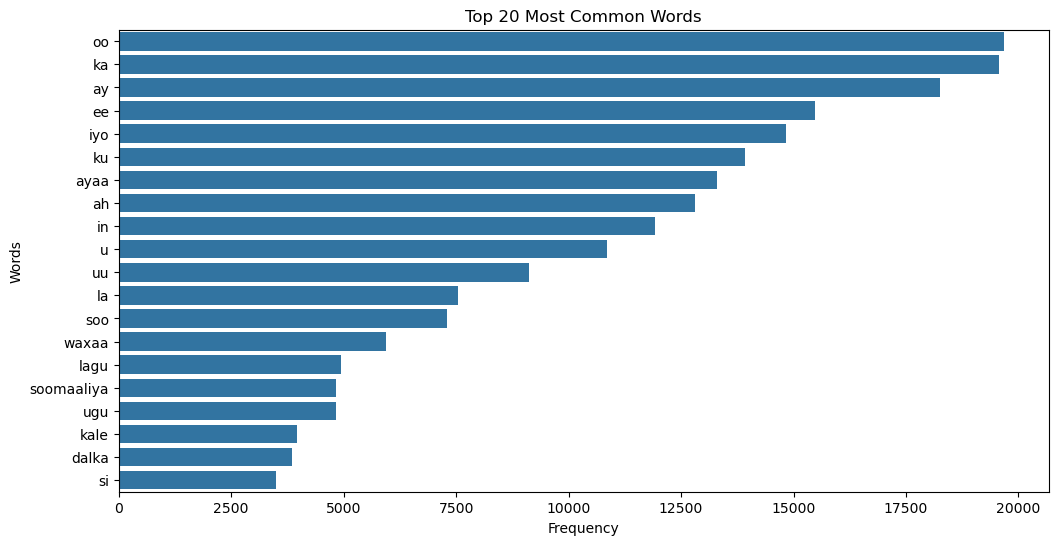

In [118]:

# Ensure folder exists

os.makedirs("eda/figures", exist_ok=True)

# Combine all text
all_words = " ".join(df['clean_text']).split()

# Count word frequency
word_freq = Counter(all_words)

# Get top 20 words
common_words = word_freq.most_common(20)

# Split into words and counts
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=counts, y=words)

plt.title("Top 20 Most Common Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

# Save figure
plt.savefig("eda/figures/top20_words.png", bbox_inches='tight')

plt.show()

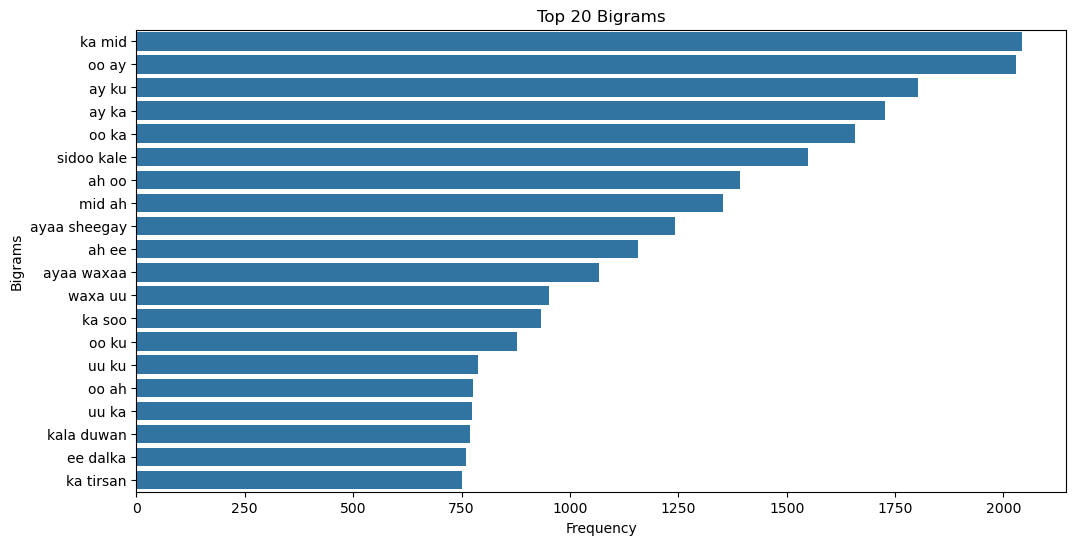

In [119]:
# Create bigram features
vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words='english'
)

# Transform text
X = vectorizer.fit_transform(df['clean_text'])

# Sum occurrences
sum_words = X.sum(axis=0)

# Convert to list
words_freq = [
    (word, sum_words[0, idx])
    for word, idx in vectorizer.vocabulary_.items()
]

# Sort top bigrams
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:20]

# Split data
words, counts = zip(*words_freq)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=list(counts), y=list(words))

plt.title("Top 20 Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")

# Save figure
plt.savefig("eda/figures/top20_bigrams.png", bbox_inches='tight')

plt.show()

In [88]:
# 1. Drop missing values
df = df.dropna(subset=['Text', 'Category'])

# 2. Convert to string
df['Text'] = df['Text'].astype(str)
df['Category'] = df['Category'].astype(str)

# 3. Clean text safely
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.strip()

df['clean_text'] = df['Text'].apply(clean_text)

# 4. Remove empty text rows (VERY IMPORTANT)
df = df[df['clean_text'] != ""]

STEP 5 — Traditional ML (Commented Code)

# TF-IDF Feature Engineering

In [89]:
# Convert text into numerical features using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,   # limit vocabulary size
    ngram_range=(1,2)    # use single words + bigrams
)

# Transform cleaned text into feature matrix
X = tfidf.fit_transform(df['clean_text'])

# Target labels
y = df['Category']

# Train-Test Split

In [90]:
# Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test data
    random_state=42     # for reproducibility
)

# Logistic Regression

In [91]:
# Import model
from sklearn.linear_model import LogisticRegression

# Create model
lr = LogisticRegression(max_iter=5000)

# Train model
lr.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

# Linear SVM

In [92]:
# Import SVM model
from sklearn.svm import LinearSVC

# Create model
svm = LinearSVC()

# Train model
svm.fit(X_train, y_train)

LinearSVC()

# Random Forest

In [93]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create model
rf = RandomForestClassifier()

# Train model
rf.fit(X_train, y_train)

RandomForestClassifier()

# XGBoost Model

In [94]:
# Remove spaces + make lowercase + standard format
df['Category'] = df['Category'].astype(str).str.strip().str.lower()

In [95]:
print(df['Category'].unique())

['sports' 'education' 'religion' 'business' 'health' 'politics'
 'entertainment' 'technology']


In [96]:
df['Category'] = df['Category'].replace({
    'health ': 'health',
    'religion ': 'religion',
})

In [97]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['Category'])

In [98]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
 

In [100]:
# Import XGBoost classifier
from xgboost import XGBClassifier

# Create model
xgb = XGBClassifier(eval_metric='logloss')

# Train model
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [101]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    n_jobs=-1
)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

# Evaluation Function

In [102]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to evaluate models
def evaluate(model, X_test, y_test):

    # Predict values
    y_pred = model.predict(X_test)

    # Print evaluation metrics
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1-score:", f1_score(y_test, y_pred, average='weighted'))
    print("-" * 40)

# Model Comparison

In [103]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Category'] = df['Category'].astype(str).str.strip().str.lower()
y = le.fit_transform(df['Category'])

In [104]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [106]:
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [107]:
# Evaluate Logistic Regression
print("Logistic Regression")
evaluate(lr, X_test, y_test)

# Evaluate SVM
print("SVM")
evaluate(svm, X_test, y_test)

# Evaluate Random Forest
print("Random Forest")
evaluate(rf, X_test, y_test)

# Evaluate XGBoost
print("XGBoost")
evaluate(xgb, X_test, y_test)

Logistic Regression
Accuracy: 0.825
Precision: 0.824491469869524
Recall: 0.825
F1-score: 0.8105161160142718
----------------------------------------
SVM
Accuracy: 0.8733333333333333
Precision: 0.8734845293735027
Recall: 0.8733333333333333
F1-score: 0.8686520419261228
----------------------------------------
Random Forest
Accuracy: 0.8533333333333334
Precision: 0.8456933020664086
Recall: 0.8533333333333334
F1-score: 0.8416626660014807
----------------------------------------
XGBoost
Accuracy: 0.8883333333333333
Precision: 0.8863461706984747
Recall: 0.8883333333333333
F1-score: 0.8859723241955257
----------------------------------------


d:\anacoda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\anacoda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# GridSearchCV (SVM tuning)

In [108]:
# Hyperparameter tuning for SVM
from sklearn.model_selection import GridSearchCV

# Define parameter grid
params = {
    'C': [0.1, 1, 10],
    'loss': ['hinge', 'squared_hinge']
}

# Create GridSearch model
grid = GridSearchCV(
    LinearSVC(),
    params,
    cv=3,
    scoring='f1_weighted'
)

# Train GridSearch
grid.fit(X_train, y_train)

# Show best parameters
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

d:\anacoda\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\anacoda\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\anacoda\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best Params: {'C': 10, 'loss': 'hinge'}
Best Score: 0.8570655012372365


d:\anacoda\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


# Report

“Waxaa la arkay warning ku saabsan convergence-ka Linear SVM, taasoo ka dhalatay in model-ku u baahday iterations dheeraad ah si uu si buuxda u tababarto. Arrintan waxaa lagu xallin karaa kordhinta max_iter.”